In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from simulate import *
from f16system import *
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import jax
import pickle

# Init constants (run every time boot up)
nominal_noise_mean = jnp.zeros(16)
nominal_noise_std = jnp.zeros(16) + 1e-10
nominal_noise_std = nominal_noise_std.at[6].set(0.005)   # Roll rate noise
nominal_noise_std = nominal_noise_std.at[3].set(0.005)     # Roll measurement noise
nominal_noise_cov = jnp.diag(jnp.square(nominal_noise_std))

# key = jax.random.key(10)
# prop_noise_arr = (jax.random.normal(key, (NUM_PTS, 300, 2))) * 0.002 + 0.002
np.random.seed(0)
prop_noise_perturb_std = 0.002


prop_noise_std = jnp.zeros(16) + 1e-10
prop_noise_std = prop_noise_std.at[6].set(prop_noise_perturb_std)     # Roll rate noise
prop_noise_std = prop_noise_std.at[3].set(prop_noise_perturb_std)     # Roll measurement noise
prop_noise_cov = jnp.diag(jnp.square(prop_noise_std))



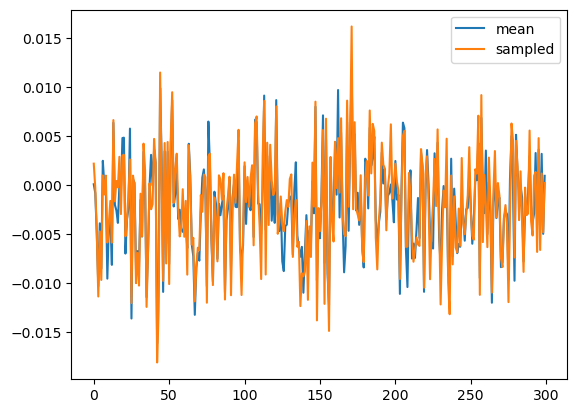

In [2]:
# # Initialize Population Monte Carlo (run once)
# p_rate_range = np.linspace(-0.003, 0.003, NUM_PTS)
# phi_range = np.linspace(-0.001, 0.001, NUM_PTS)
# ranges = np.meshgrid(p_rate_range, phi_range)
# p_means = ranges[0].reshape((-1,1))
# phi_means = ranges[1].reshape((-1,1))
# p_stds = np.ones(p_means.shape[0]) * 0.005
# phi_stds = np.ones(p_means.shape[0]) * 0.005

DIM_RANGE = 8
NUM_PTS = DIM_RANGE * DIM_RANGE

priming_noise_perturb = 0.005
prime_noise_arr = np.random.randn(NUM_PTS, 300, 2) * priming_noise_perturb
noise_arr = np.random.randn(NUM_PTS, 300, 2) * prop_noise_perturb_std
p_rate_range = np.linspace(-0.003, 0.003, DIM_RANGE)
phi_range = np.linspace(-0.002, 0.002, DIM_RANGE)
p_range, phi_range = np.meshgrid(p_rate_range, phi_range)
prop_noise_mean_traj = np.zeros_like(noise_arr)
prop_noise_mean_traj = np.hstack((p_range.reshape((-1,1)), phi_range.reshape((-1,1))))[:,np.newaxis,:] + prime_noise_arr
prop_sampled_noise_mean_traj = prop_noise_mean_traj + noise_arr

plt.figure()
plt.plot(prop_noise_mean_traj[1,:,1])
plt.plot(prop_sampled_noise_mean_traj[1,:,1])
plt.legend(["mean", "sampled"])


all_importance_weights = [0]
save_checkpoint_name = "checkpoints/checkpoint_0.p"


In [4]:
# Load checkpoint to continue experiment
load_checkpoint_name = "checkpoints/checkpoint_0.p"
save_checkpoint_name = "checkpoints/checkpoint_1.p"
data = pickle.load(open(load_checkpoint_name, "rb"))
prop_sampled_noise_mean_traj = data['prop_sampled_noise_mean_traj']
prop_noise_mean_traj = data['prop_noise_mean_traj']
all_importance_weights = data['imp_weights']

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints/checkpoint_0.p'

In [4]:
# Population Monte Carlo

max_iter = 1
for iter in range(max_iter):
    new_means = []
    new_std = []
    importance_weights = []
    for i in tqdm(range(NUM_PTS), desc="Proposal Distributions"):
        # p_mu = p_means[i]
        # phi_mu = phi_means[i]
        
        # p_std = p_stds[i]
        # phi_std = phi_stds[i]

        # prop_noise_mean = prop_noise_mean.at[6].set(p_mu.item())   # Roll rate noise
        # prop_noise_mean = prop_noise_mean.at[3].set(phi_mu.item())   # Altimeter rate noise
        # prop_noise_std = prop_noise_std.at[6].set(p_std.item())   # Roll rate noise
        # prop_noise_std = prop_noise_std.at[3].set(phi_std.item())     # Roll measurement noise
        # prop_noise_cov = jnp.diag(jnp.square(prop_noise_std))

        system = F16System(
            T=300,
            dt=1/500,
            euler_steps=10,
            power=9,
            alpha=deg2rad(2.1215),
            beta=0.0,
            alt=600.0,
            vt=540.0,
            phi=-math.pi/8,
            theta=(-math.pi/2) * 0.3,
            psi=0.0,
            p=0.0,
            q=0.0,
            r=0.0,
            sensor_seed=iter*NUM_PTS + i,
            prop_noise_mean=None,
            prop_noise_std=None,
            determ_noise_arr=prop_sampled_noise_mean_traj[i])
        min_alt, cum_log_like, progression = system.rollout_min_altitude_and_loglik()
        print(min_alt, cum_log_like, gaussian_log_pdf_from_noise_arr(progression[2], prop_noise_mean_traj[i,:,:], prop_noise_cov))
        if (min_alt < CRASH_ALT):
            disturbance_array = progression[2]
            states_of_interest = np.stack((disturbance_array[:,6], disturbance_array[:,3]),axis=1)
            new_means.append(states_of_interest)
            # new_std.append(jnp.std(states_of_interest, axis=0))
            nom_log_pdf = jnp.sum(gaussian_log_pdf_traj(disturbance_array, nominal_noise_mean, nominal_noise_cov))
            prop_log_pdf = gaussian_log_pdf_from_noise_arr(disturbance_array, prop_noise_mean_traj[i,:,:], prop_noise_cov)
            print(cum_log_like, nom_log_pdf, prop_log_pdf,cum_log_like - prop_log_pdf)
            importance_weights.append(np.exp(cum_log_like - prop_log_pdf, dtype=np.float64))

            all_importance_weights.append(importance_weights[-1])
        else:
            all_importance_weights.append(0)
    
    # Resample proposal distributions
    if (len(importance_weights) != 0):
        print(importance_weights)
        importance_probs = importance_weights / np.sum(importance_weights)
        resampled_ind = np.random.choice(np.arange(0,len(importance_weights),1), size=NUM_PTS, p=importance_probs)

        print("PROBABILITY OF FAILURE ESTIMATE:", np.mean(all_importance_weights))
        print(importance_probs)
        print(resampled_ind)
        
        for i in range(NUM_PTS):
            ind = resampled_ind[i]
            prop_noise_mean_traj[i,:,:] = new_means[ind]
        noise_arr = np.random.randn(NUM_PTS, 300, 2) * prop_noise_perturb_std
        prop_sampled_noise_mean_traj = noise_arr + prop_noise_mean_traj
    else:
        print("idk man")        
      

    # Save to pickle file
    data = {
        "prop_sampled_noise_mean_traj": prop_sampled_noise_mean_traj,
        "prop_noise_mean_traj": prop_noise_mean_traj,
        "imp_weights": all_importance_weights
    }
    pickle.dump(data, open(save_checkpoint_name, "wb"))


Proposal Distributions:   0%|          | 0/64 [00:00<?, ?it/s]

Proposal Distributions:   2%|▏         | 1/64 [00:10<11:05, 10.56s/it]

19.956594 95040.39 95734.09


Proposal Distributions:   3%|▎         | 2/64 [00:19<10:10,  9.84s/it]

19.962381 95106.84 95707.836


...

14.505375 95106.445 95700.84


Proposal Distributions:  98%|█████████▊| 63/64 [10:12<00:10, 10.11s/it]

4.0904946 95094.12 95731.11


Proposal Distributions: 100%|██████████| 64/64 [10:21<00:00,  9.71s/it]

9.251065 95036.516 95728.49
[2.7502567811560816e-288, 5.980047106895248e-279]
PROBABILITY OF FAILURE ESTIMATE: 9.2000724763777e-281
[4.59905538e-10 1.00000000e+00]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


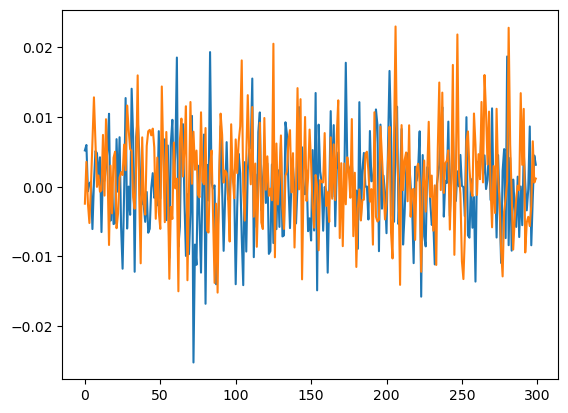

In [ ]:
plt.plot(prop_sampled_noise_mean_traj[1])

In [5]:
for i in range(NUM_PTS):
    ind = resampled_ind[i]
    prop_noise_mean_traj[i,:,:] = new_means[ind]
noise_arr = np.random.randn(NUM_PTS, 300, 2) * prop_noise_perturb_std
prop_sampled_noise_mean_traj = noise_arr + prop_noise_mean_traj

IndexError: list index out of range

(10, 16)
[0.         0.         0.         0.00300079 0.         0.
 0.00982026 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[0.         0.         0.         0.01220447 0.         0.
 0.00589369 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[ 0.          0.          0.         -0.00388639  0.          0.
  0.01033779  0.          0.          0.          0.          0.
  0.          0.          0.          0.        ]
[0.         0.         0.         0.00024321 0.         0.
 0.00575044 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[0.         0.         0.         0.00305299 0.         0.
 0.00048391 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[0.         0.         0.         0.00827137 0.         0.
 0.00172022 0.         0.         0.         0.         0.
 0.         0.         0.         0. 

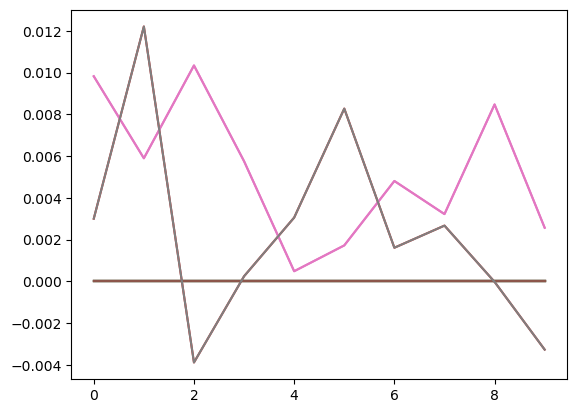

In [ ]:
disturbance_array = progression[2]
print(disturbance_array.shape)
plt.plot(disturbance_array)
plt.plot(prop_noise_arr[0])
prop_log_pdf = gaussian_log_pdf_from_noise_arr(disturbance_array, prop_noise_arr[0], prop_noise_cov)
print(prop_log_pdf)

Text(0.5, 1.0, 'Population Monte Carlo Convergence')

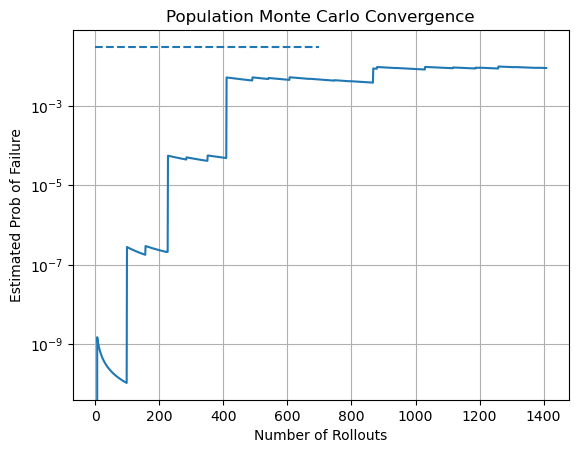

In [ ]:
data = np.cumsum(all_importance_weights)
plt.semilogy(data / np.arange(1, data.shape[0]+1, 1))
plt.hlines(0.03, 0, 700, linestyles='--')
plt.grid('on')
plt.xlabel("Number of Rollouts")
plt.ylabel("Estimated Prob of Failure")
plt.title("Population Monte Carlo Convergence")

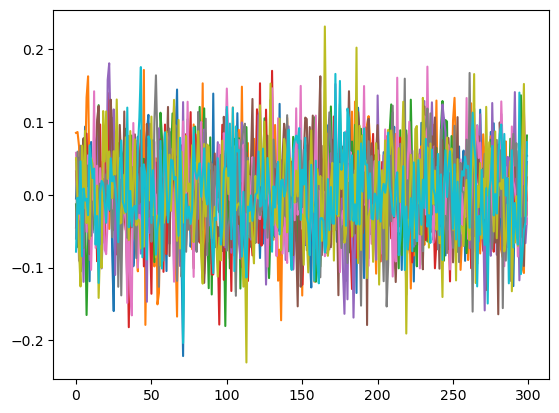

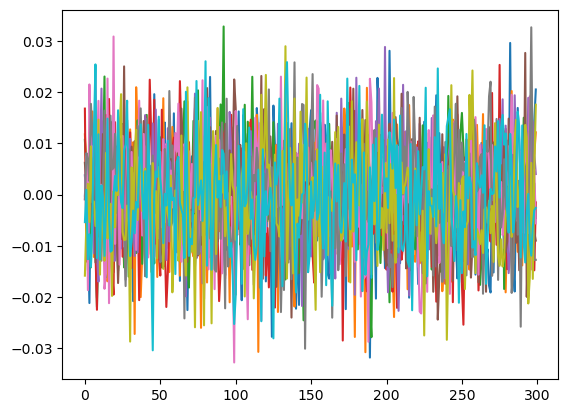

In [ ]:
plt.plot(np.stack((disturbance_array[:,:,6],disturbance_array[:,:,3]),axis=2)[:,:,0])
plt.figure()
plt.plot(np.stack((disturbance_array[:,:,6],disturbance_array[:,:,3]),axis=2)[:,:,1])

(300, 10, 16)


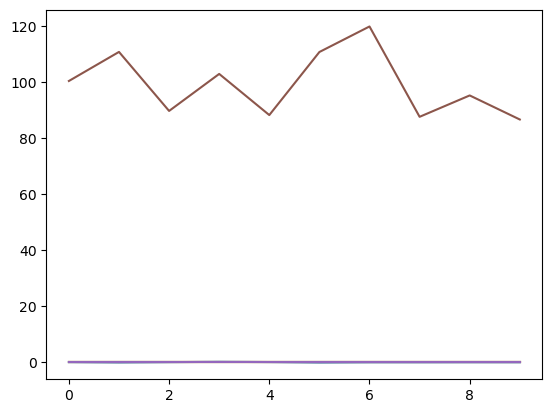

In [ ]:
print(progression[2].shape)
plt.plot(progression[2][1,:,6:12])

In [ ]:
jnp.sum(gaussian_log_pdf_traj(disturbance_array, prop_noise_mean, prop_noise_cov))

Array(87249.055, dtype=float32)